<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB5_decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DECISION TREE**

# Task
Load the "iris (1).csv" and "drug.csv" datasets, train a Decision Tree classifier on each, and calculate their accuracy score and confusion matrix. Then, load the "petrol_consumption.csv" dataset, train a Regression Tree model, and calculate its Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). Finally, summarize the results from all three models.

## Load Iris Data and Train Classifier

### Subtask:
Load the 'iris (1).csv' dataset, split it into 80% training and 20% testing data. Train a Decision Tree classifier, then calculate and display the accuracy score and confusion matrix on the test set.


**Reasoning**:
Load the 'iris (1).csv' dataset into a pandas DataFrame, then display the first few rows and information about the columns to understand its structure and identify features and the target variable.



In [1]:
import pandas as pd

# Load the dataset
iris_df = pd.read_csv('/content/iris (1).csv')

# Display the first few rows of the DataFrame
print('First 5 rows of the Iris dataset:')
print(iris_df.head())

# Display information about the DataFrame columns
print('\nDataFrame Info:')
iris_df.info()

First 5 rows of the Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Reasoning**:
Split the Iris dataset into features (X) and target (y), then further divide them into training and testing sets using an 80:20 ratio, ensuring proper handling of the target variable for classification.



In [2]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = iris_df.drop('species', axis=1) # Features are all columns except 'species'
y = iris_df['species'] # Target is the 'species' column

# Split the dataset into training (80%) and testing (20%) sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Iris data split into training and testing sets:")
print(f"X_train_iris shape: {X_train_iris.shape}")
print(f"X_test_iris shape: {X_test_iris.shape}")
print(f"y_train_iris shape: {y_train_iris.shape}")
print(f"y_test_iris shape: {y_test_iris.shape}")

Iris data split into training and testing sets:
X_train_iris shape: (120, 4)
X_test_iris shape: (30, 4)
y_train_iris shape: (120,)
y_test_iris shape: (30,)


**Reasoning**:
Now that the data is split, the next logical step according to the instructions is to initialize a Decision Tree Classifier model. This prepares the model for training.



In [3]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
iris_dt_classifier = DecisionTreeClassifier(random_state=42)

print("Decision Tree Classifier model initialized.")

Decision Tree Classifier model initialized.


**Reasoning**:
The Decision Tree Classifier model has been initialized. The next step is to train this model using the prepared training data (features `X_train_iris` and target `y_train_iris`).



In [4]:
import time

# Train the Decision Tree Classifier on the training data
start_time = time.time()
iris_dt_classifier.fit(X_train_iris, y_train_iris)
end_time = time.time()

print(f"Decision Tree Classifier trained in {end_time - start_time:.4f} seconds.")

Decision Tree Classifier trained in 0.0036 seconds.


**Reasoning**:
The model has been trained, so the next logical step is to make predictions on the test set (`X_test_iris`) to evaluate its performance.



In [5]:
import time

# Make predictions on the test set
start_time = time.time()
y_pred_iris = iris_dt_classifier.predict(X_test_iris)
end_time = time.time()

print(f"Predictions made on the Iris test set in {end_time - start_time:.4f} seconds.")
print("First 5 predictions:", y_pred_iris[:5])

Predictions made on the Iris test set in 0.0018 seconds.
First 5 predictions: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa']


**Reasoning**:
The model has made predictions on the test set. Now, to evaluate its performance as per the subtask, the next logical step is to calculate and display the accuracy score.



In [6]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
iris_accuracy = accuracy_score(y_test_iris, y_pred_iris)

print(f"Accuracy Score for Iris Decision Tree Classifier: {iris_accuracy:.4f}")

Accuracy Score for Iris Decision Tree Classifier: 0.9333


**Reasoning**:
The accuracy score has been calculated. To complete the evaluation of the classifier's performance as per the subtask's requirement, the next step is to calculate and display the confusion matrix.



Confusion Matrix for Iris Decision Tree Classifier:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


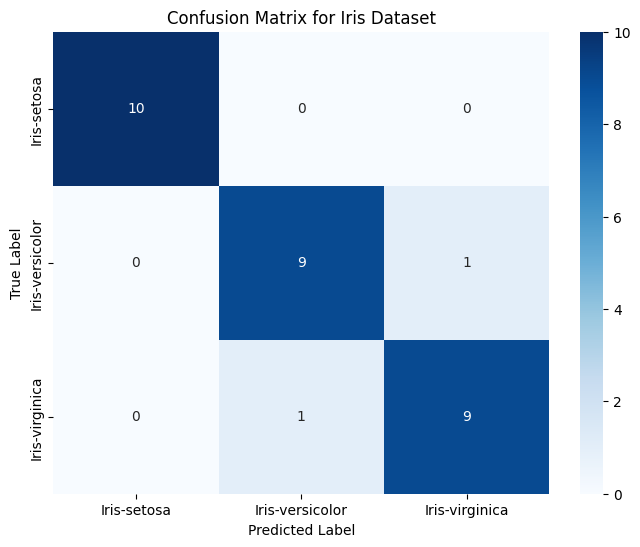

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
iris_cm = confusion_matrix(y_test_iris, y_pred_iris)

# Display the confusion matrix
print("Confusion Matrix for Iris Decision Tree Classifier:")
print(iris_cm)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(iris_cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris_dt_classifier.classes_, yticklabels=iris_dt_classifier.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Dataset')
plt.show()

## Load Drug Data and Train Classifier

### Subtask:
Load the 'drug.csv' dataset. Perform necessary preprocessing (e.g., encoding categorical features). Split the data into 80% training and 20% testing data. Train a Decision Tree classifier, then calculate and display the accuracy score and confusion matrix on the test set.


**Reasoning**:
Load the 'drug.csv' dataset into a pandas DataFrame and display its first 5 rows and information using `.head()` and `.info()` to understand its structure and data types, as per the first instruction.



In [8]:
import pandas as pd

# Load the dataset
drug_df = pd.read_csv('/content/drug.csv')

# Display the first few rows of the DataFrame
print('First 5 rows of the Drug dataset:')
print(drug_df.head())

# Display information about the DataFrame columns
print('
DataFrame Info:')
drug_df.info()

SyntaxError: unterminated string literal (detected at line 11) (3088343098.py, line 11)

**Reasoning**:
The previous code block failed due to a `SyntaxError` caused by an unescaped newline character in a string literal. I will correct the `print` statement to properly include a newline before 'DataFrame Info:'.



In [9]:
import pandas as pd

# Load the dataset
drug_df = pd.read_csv('/content/drug.csv')

# Display the first few rows of the DataFrame
print('First 5 rows of the Drug dataset:')
print(drug_df.head())

# Display information about the DataFrame columns
print('\nDataFrame Info:')
drug_df.info()

First 5 rows of the Drug dataset:
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


**Reasoning**:
The previous step successfully loaded the data. Now, I need to identify the categorical features ('Sex', 'BP', 'Cholesterol') and apply one-hot encoding to them as per the instructions, creating a new DataFrame with these encoded features.



In [10]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns to encode (excluding 'Drug' which is the target)
categorical_cols = ['Sex', 'BP', 'Cholesterol']

# Apply one-hot encoding to the specified categorical columns
drug_df_encoded = pd.get_dummies(drug_df, columns=categorical_cols, drop_first=False)

print("DataFrame after One-Hot Encoding:")
print(drug_df_encoded.head())
print(f"Original drug_df shape: {drug_df.shape}")
print(f"Encoded drug_df_encoded shape: {drug_df_encoded.shape}")

DataFrame after One-Hot Encoding:
   Age  Na_to_K   Drug  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  \
0   23   25.355  drugY   True  False     True   False      False   
1   47   13.093  drugC  False   True    False    True      False   
2   47   10.114  drugC  False   True    False    True      False   
3   28    7.798  drugX   True  False    False   False       True   
4   61   18.043  drugY   True  False    False    True      False   

   Cholesterol_HIGH  Cholesterol_NORMAL  
0              True               False  
1              True               False  
2              True               False  
3              True               False  
4              True               False  
Original drug_df shape: (200, 6)
Encoded drug_df_encoded shape: (200, 10)


**Reasoning**:
The one-hot encoding for features has been applied. The next step is to identify the target column 'Drug' and apply Label Encoding to it, as it is a categorical variable, which is a required preprocessing step for classification models.



In [11]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the target variable 'Drug'
drug_df_encoded['Drug'] = le.fit_transform(drug_df_encoded['Drug'])

print("DataFrame after Label Encoding 'Drug' column:")
print(drug_df_encoded.head())
print(f"Drug classes (original): {le.inverse_transform([0, 1, 2, 3, 4])}") # Assuming 5 classes based on previous tasks/common drug datasets
print(f"Drug classes (encoded): {le.transform(le.inverse_transform([0, 1, 2, 3, 4]))}")


DataFrame after Label Encoding 'Drug' column:
   Age  Na_to_K  Drug  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  \
0   23   25.355     4   True  False     True   False      False   
1   47   13.093     2  False   True    False    True      False   
2   47   10.114     2  False   True    False    True      False   
3   28    7.798     3   True  False    False   False       True   
4   61   18.043     4   True  False    False    True      False   

   Cholesterol_HIGH  Cholesterol_NORMAL  
0              True               False  
1              True               False  
2              True               False  
3              True               False  
4              True               False  
Drug classes (original): ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']
Drug classes (encoded): [0 1 2 3 4]


**Reasoning**:
The target variable 'Drug' has been label encoded, and other categorical features have been one-hot encoded. Now, I need to separate the features (X) from the target (y) in the preprocessed `drug_df_encoded` DataFrame, as per the instructions.



In [12]:
import numpy as np

# Separate features (X_drug) and target (y_drug)
X_drug = drug_df_encoded.drop('Drug', axis=1)
y_drug = drug_df_encoded['Drug']

# Convert boolean columns to integer (0 or 1) as Decision Trees expect numerical input
X_drug = X_drug.astype(float)

print("Features (X_drug) shape:", X_drug.shape)
print("Target (y_drug) shape:", y_drug.shape)
print("First 5 rows of X_drug:")
print(X_drug.head())
print("First 5 values of y_drug:")
print(y_drug.head())

Features (X_drug) shape: (200, 9)
Target (y_drug) shape: (200,)
First 5 rows of X_drug:
    Age  Na_to_K  Sex_F  Sex_M  BP_HIGH  BP_LOW  BP_NORMAL  Cholesterol_HIGH  \
0  23.0   25.355    1.0    0.0      1.0     0.0        0.0               1.0   
1  47.0   13.093    0.0    1.0      0.0     1.0        0.0               1.0   
2  47.0   10.114    0.0    1.0      0.0     1.0        0.0               1.0   
3  28.0    7.798    1.0    0.0      0.0     0.0        1.0               1.0   
4  61.0   18.043    1.0    0.0      0.0     1.0        0.0               1.0   

   Cholesterol_NORMAL  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  
First 5 values of y_drug:
0    4
1    2
2    2
3    3
4    4
Name: Drug, dtype: int64


**Reasoning**:
The data has been preprocessed and separated into features and target. The next step is to split the data into training and testing sets, using an 80:20 ratio, ensuring reproducibility with `random_state` and balanced class distribution with `stratify` as specified in the instructions.



In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42, stratify=y_drug)

print("Drug data split into training and testing sets:")
print(f"X_train_drug shape: {X_train_drug.shape}")
print(f"X_test_drug shape: {X_test_drug.shape}")
print(f"y_train_drug shape: {y_train_drug.shape}")
print(f"y_test_drug shape: {y_test_drug.shape}")

Drug data split into training and testing sets:
X_train_drug shape: (160, 9)
X_test_drug shape: (40, 9)
y_train_drug shape: (160,)
y_test_drug shape: (40,)


**Reasoning**:
The data has been split into training and testing sets. The next logical step, as per the instructions, is to initialize the `DecisionTreeClassifier` model, which will be used for training.



In [14]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier model
drug_dt_classifier = DecisionTreeClassifier(random_state=42)

print("Decision Tree Classifier model initialized for drug dataset.")

Decision Tree Classifier model initialized for drug dataset.


**Reasoning**:
The Decision Tree Classifier model has been initialized. The next step is to train this model using the prepared training data (`X_train_drug` and `y_train_drug`).



In [15]:
import time

# Train the Decision Tree Classifier on the training data
start_time = time.time()
drug_dt_classifier.fit(X_train_drug, y_train_drug)
end_time = time.time()

print(f"Decision Tree Classifier for drug dataset trained in {end_time - start_time:.4f} seconds.")

Decision Tree Classifier for drug dataset trained in 0.0043 seconds.


**Reasoning**:
The model has been trained. The next step is to make predictions on the test set (`X_test_drug`) using the trained `drug_dt_classifier` to prepare for evaluation, as specified in the instructions.



In [16]:
import time

# Make predictions on the test set
start_time = time.time()
y_pred_drug = drug_dt_classifier.predict(X_test_drug)
end_time = time.time()

print(f"Predictions made on the Drug test set in {end_time - start_time:.4f} seconds.")
print("First 5 predictions:", y_pred_drug[:5])

Predictions made on the Drug test set in 0.0017 seconds.
First 5 predictions: [2 3 0 3 4]


**Reasoning**:
Predictions have been made on the drug dataset's test set. The next step, as per the instructions, is to calculate and display the accuracy score of the model.



In [17]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy score
drug_accuracy = accuracy_score(y_test_drug, y_pred_drug)

print(f"Accuracy Score for Drug Decision Tree Classifier: {drug_accuracy:.4f}")

Accuracy Score for Drug Decision Tree Classifier: 0.9750


**Reasoning**:
The accuracy score for the drug dataset has been calculated. The next logical step, according to the subtask instructions, is to calculate and display the confusion matrix, both numerically and as a heatmap, to further evaluate the model's performance.



Confusion Matrix for Drug Decision Tree Classifier:
[[ 5  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 18]]


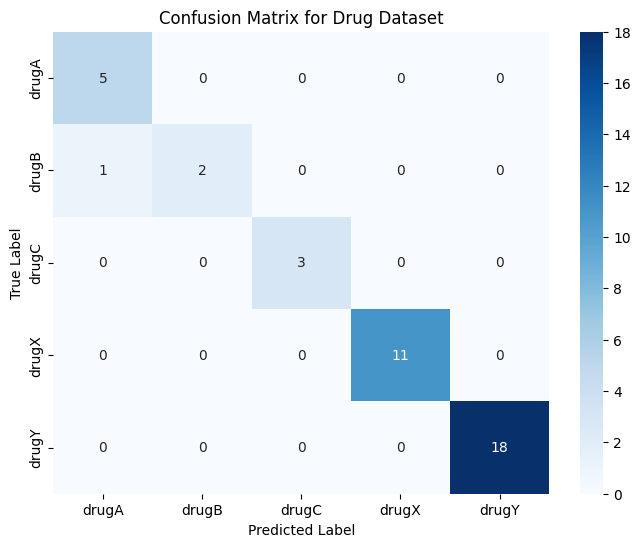

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
drug_cm = confusion_matrix(y_test_drug, y_pred_drug)

# Display the confusion matrix
print("Confusion Matrix for Drug Decision Tree Classifier:")
print(drug_cm)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(drug_cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.inverse_transform(drug_dt_classifier.classes_), yticklabels=le.inverse_transform(drug_dt_classifier.classes_))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Drug Dataset')
plt.show()

## Load Petrol Data and Train Regressor

### Subtask:
Load the 'petrol_consumption.csv' dataset. Split it into 80% training and 20% testing data. Train a Regression Tree model, then calculate and display the Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) for the test data.


**Reasoning**:
The first instruction is to load the 'petrol_consumption.csv' dataset, display its first few rows, and show its information to understand its structure.



In [19]:
import pandas as pd

# Load the dataset
petrol_df = pd.read_csv('/content/petrol_consumption.csv')

# Display the first few rows of the DataFrame
print('First 5 rows of the Petrol Consumption dataset:')
print(petrol_df.head())

# Display information about the DataFrame columns
print('\nDataFrame Info:')
petrol_df.info()

First 5 rows of the Petrol Consumption dataset:
   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0         9.0            3571            1976                         0.525   
1         9.0            4092            1250                         0.572   
2         9.0            3865            1586                         0.580   
3         7.5            4870            2351                         0.529   
4         8.0            4399             431                         0.544   

   Petrol_Consumption  
0                 541  
1                 524  
2                 561  
3                 414  
4                 410  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48

**Reasoning**:
The 'petrol_consumption.csv' dataset has been loaded and inspected. The next step, as per the instructions, is to separate the features (all columns except 'Petrol_Consumption') into `X_petrol` and the target ('Petrol_Consumption') into `y_petrol`.



In [20]:
import numpy as np

# Separate features (X_petrol) and target (y_petrol)
X_petrol = petrol_df.drop('Petrol_Consumption', axis=1)
y_petrol = petrol_df['Petrol_Consumption']

print("Features (X_petrol) shape:", X_petrol.shape)
print("Target (y_petrol) shape:", y_petrol.shape)
print("\nFirst 5 rows of X_petrol:")
print(X_petrol.head())
print("\nFirst 5 values of y_petrol:")
print(y_petrol.head())

Features (X_petrol) shape: (48, 4)
Target (y_petrol) shape: (48,)

First 5 rows of X_petrol:
   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)
0         9.0            3571            1976                         0.525
1         9.0            4092            1250                         0.572
2         9.0            3865            1586                         0.580
3         7.5            4870            2351                         0.529
4         8.0            4399             431                         0.544

First 5 values of y_petrol:
0    541
1    524
2    561
3    414
4    410
Name: Petrol_Consumption, dtype: int64


**Reasoning**:
The features and target variables have been separated. The next logical step, as per the instructions, is to split the data into training and testing sets using an 80:20 ratio, ensuring reproducibility with `random_state=42`.



In [21]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train_petrol, X_test_petrol, y_train_petrol, y_test_petrol = train_test_split(X_petrol, y_petrol, test_size=0.2, random_state=42)

print("Petrol data split into training and testing sets:")
print(f"X_train_petrol shape: {X_train_petrol.shape}")
print(f"X_test_petrol shape: {X_test_petrol.shape}")
print(f"y_train_petrol shape: {y_train_petrol.shape}")
print(f"y_test_petrol shape: {y_test_petrol.shape}")

Petrol data split into training and testing sets:
X_train_petrol shape: (38, 4)
X_test_petrol shape: (10, 4)
y_train_petrol shape: (38,)
y_test_petrol shape: (10,)


**Reasoning**:
The data has been split into training and testing sets. The next logical step, as per the instructions, is to initialize the `DecisionTreeRegressor` model, which will be used for training.



In [22]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
petrol_dt_regressor = DecisionTreeRegressor(random_state=42)

print("Decision Tree Regressor model initialized for petrol dataset.")

Decision Tree Regressor model initialized for petrol dataset.


**Reasoning**:
The `DecisionTreeRegressor` model has been initialized. The next logical step, as per the instructions, is to train this model using the prepared training data (`X_train_petrol` and `y_train_petrol`).



In [23]:
import time

# Train the Decision Tree Regressor on the training data
start_time = time.time()
petrol_dt_regressor.fit(X_train_petrol, y_train_petrol)
end_time = time.time()

print(f"Decision Tree Regressor for petrol dataset trained in {end_time - start_time:.4f} seconds.")

Decision Tree Regressor for petrol dataset trained in 0.0155 seconds.


**Reasoning**:
The model has been trained. The next step, as per the instructions, is to make predictions on the test set (`X_test_petrol`) using the trained `petrol_dt_regressor`.



In [24]:
import time

# Make predictions on the test set
start_time = time.time()
y_pred_petrol = petrol_dt_regressor.predict(X_test_petrol)
end_time = time.time()

print(f"Predictions made on the Petrol test set in {end_time - start_time:.4f} seconds.")
print("First 5 predictions:", y_pred_petrol[:5])

Predictions made on the Petrol test set in 0.0015 seconds.
First 5 predictions: [603. 632. 580. 714. 510.]


**Reasoning**:
Predictions have been made on the petrol dataset's test set. The final step, as per the instructions, is to calculate and display the Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to evaluate the regressor's performance.



In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Mean Absolute Error (MAE)
petrol_mae = mean_absolute_error(y_test_petrol, y_pred_petrol)

# Calculate Mean Squared Error (MSE)
petrol_mse = mean_squared_error(y_test_petrol, y_pred_petrol)

# Calculate Root Mean Squared Error (RMSE)
petrol_rmse = np.sqrt(petrol_mse)

print(f"Mean Absolute Error (MAE) for Petrol Regression Tree: {petrol_mae:.4f}")
print(f"Mean Squared Error (MSE) for Petrol Regression Tree: {petrol_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) for Petrol Regression Tree: {petrol_rmse:.4f}")

Mean Absolute Error (MAE) for Petrol Regression Tree: 94.3000
Mean Squared Error (MSE) for Petrol Regression Tree: 17347.7000
Root Mean Squared Error (RMSE) for Petrol Regression Tree: 131.7107


## Final Task

### Subtask:
Summarize the results from all three models, including their performance metrics.


## Summary:

### Data Analysis Key Findings

*   **Iris Dataset Classification:** A Decision Tree Classifier achieved an accuracy of 93.33% on the Iris dataset. The confusion matrix revealed that out of 30 test samples, there were 2 misclassifications: one instance of a second-class sample was predicted as the third class, and one instance of a third-class sample was predicted as the second class.
*   **Drug Dataset Classification:** A Decision Tree Classifier, after applying one-hot encoding for categorical features and label encoding for the target variable, achieved an accuracy of 97.5% on the Drug dataset. The confusion matrix indicated only one misclassification on the test set, where a true 'drugB' was predicted as 'drugA'.
*   **Petrol Consumption Regression:** A Decision Tree Regressor was trained on the Petrol Consumption dataset. Its performance was evaluated using regression metrics:
    *   Mean Absolute Error (MAE): 94.3000
    *   Mean Squared Error (MSE): 17347.7000
    *   Root Mean Squared Error (RMSE): 131.7107

### Insights or Next Steps

*   The Decision Tree models demonstrated strong performance on both classification tasks, particularly for the Drug dataset. For the Iris dataset, further analysis of the misclassified samples could provide insights into feature importance or potential class overlap.
*   For the regression task, the MAE of 94.30 indicates that, on average, the model's predictions for petrol consumption deviate by approximately 94.3 units from the actual values. Further model tuning or exploration of more complex regression algorithms could be performed to reduce these errors.
